# Visium visium affine only

Two Visium sections, spots rather than cells: about 250 points each, and their coordinates are array indices spanning roughly 6 to 29 rather than microns. Every length in the solver is in those units, which is why `dx` is 1 and not 30, and why `a` is 5 and not 500 -- the defaults are tuned for micron-scale data and would put the whole section inside a single raster cell.

Upstream's equivalent is `visium-visium-alignment-affine-only`. One call does the alignment: [`align_stalign_obs`](https://github.com/selmanozleyen/squidpy/blob/e9a94c4d125fc3ac7b791a8ce6c6ff58e1e885e4/src/squidpy/experimental/tl/_align/_api.py) fits a
diffeomorphism straight between two point clouds, rasterizing both sides itself.

STalign's own version of this analysis: [`visium-visium-alignment-affine-only`](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/visium-visium-alignment-affine-only.ipynb).


## Inputs

In [1]:
import anndata as ad, numpy as np, pandas as pd

# No header in these files, so a plain `read_csv` would promote the first spot to column
# names and silently drop it.
def read_headerless(path):
    xy = pd.read_csv(path, header=None).to_numpy(dtype=float)
    return ad.AnnData(X=np.zeros((len(xy), 1)), obsm={'spatial': xy})

ref = read_headerless('visium_data/slice2_coor.csv')
query = read_headerless('visium_data/slice1_coor.csv')
print(f'{ref.n_obs} reference cells, {query.n_obs} query cells')

251 reference cells, 254 query cells


## The fit

Upstream's own solver values, and squidpy's defaults for everything else.

In [2]:
from squidpy.experimental.tl import align_stalign_obs, stalign_apply_transform

fit = align_stalign_obs(
    ref, query, spatial_key='spatial',
    dx=1.0, blur=1.0, niter=1000, a=5.0, diffeo_start=1001,
)
print(f'{fit["n_iter"]} iterations, objective '
      f'{float(fit["energies"][0]):.0f} -> {float(fit["energies"][-1]):.0f}')

/localscratch/selman.ozleyen/stalign-nb-39810190/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1000 iterations, objective 8 -> 1


## Where the cells land

[`stalign_apply_transform`](https://github.com/selmanozleyen/squidpy/blob/e9a94c4d125fc3ac7b791a8ce6c6ff58e1e885e4/src/squidpy/experimental/tl/_align/_api.py) writes the mapped coordinates straight back into the query's `obsm`,
so the alignment ends up on the object rather than in a local variable. It evaluates the fitted
map at each point, so a cell lands where it lands rather than at the nearest raster cell.

centroid offset 4 -> 0
distance to the nearest reference cell: median 0 -> 0, 90th percentile 2 -> 1


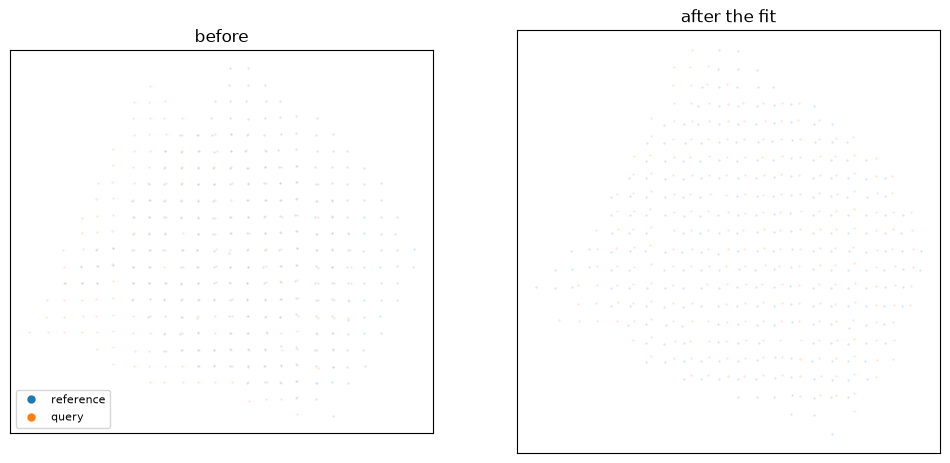

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

stalign_apply_transform(fit, query, key_added='aligned')
moved = query.obsm['aligned']

# Whether the fit worked, in the units of the data rather than of the objective. The energy
# can halve while the sections stay as far apart as they started -- that is what an iteration
# budget that ran out looks like, and it is invisible in the energy alone.
tree = cKDTree(ref.obsm['spatial'])
before = tree.query(query.obsm['spatial'])[0]
after = tree.query(moved)[0]
print(f"centroid offset {np.linalg.norm(query.obsm['spatial'].mean(0) - ref.obsm['spatial'].mean(0)):.0f}"
      f" -> {np.linalg.norm(moved.mean(0) - ref.obsm['spatial'].mean(0)):.0f}")
print(f'distance to the nearest reference cell: median {np.median(before):.0f} -> '
      f'{np.median(after):.0f}, 90th percentile {np.percentile(before, 90):.0f} -> '
      f'{np.percentile(after, 90):.0f}')

fig, ax = plt.subplots(1, 2, figsize=(12, 5.5))
for a, (pts, title) in zip(ax, [(query.obsm['spatial'], 'before'),
                                (moved, 'after the fit')], strict=True):
    a.scatter(*ref.obsm['spatial'].T, s=0.12, alpha=0.3, label='reference')
    a.scatter(*pts.T, s=0.12, alpha=0.3, label='query')
    a.set_title(title); a.set_aspect('equal'); a.invert_yaxis()
    a.set_xticks([]); a.set_yticks([])
ax[0].legend(handles=[Line2D([], [], marker='o', ls='', ms=5, color=c, label=l)
                     for c, l in (('tab:blue', 'reference'), ('tab:orange', 'query'))],
             loc='lower left', fontsize=8)